In [5]:
import matplotlib.pyplot as plt  # Import library for direct plotting functions
import numpy as np  # Import Numerical Python
from IPython.display import display, HTML  # Import HTML for formatting output
from arc import *  # Import ARC (Alkali Rydberg Calculator)
from scipy.constants import hbar, e, h, c

from DataProcessing import Readout
import matplotlib.pyplot as plt
from matplotlib import rcParams

# rcParams['font.family'] = 'Times New Roman'
rcParams['mathtext.fontset'] = 'stix'
rcParams['axes.unicode_minus'] = False
rcParams.update({
	'font.size': 14,
	'axes.titlesize': 14,
	'axes.labelsize': 14,
	'xtick.labelsize': 14,
	'ytick.labelsize': 14,
	'legend.fontsize': 14,
	'figure.titlesize': 14,
	'legend.frameon': False,
})

In [2]:
Rb85 = Rubidium85()
calc = StarkMap(Rb85)

# the target states follow the order: n, l, j, mj

target_states = [
    [60, 2, 5/2, 5/2],
    [60, 2, 5/2, 3/2],
    [60, 2, 5/2, 1/2],
    [60, 2, 3/2, 3/2],
    [60, 2, 3/2, 1/2]
]
target_index = []
target_EnergyShift = []
nmax = 65
nmin = 55
# Maximum value of l to include (l~20 gives good convergence for states with l<5)
lmax = 20

N = 400
electric_field = np.linspace(-100, 100, N)


for id_ts,ts in enumerate(target_states):
    calc.defineBasis(target_states[id_ts][0], 
                     target_states[id_ts][1], 
                     target_states[id_ts][2], 
                     target_states[id_ts][3], 
                     nmin, 
                     nmax, 
                     lmax, 
                     progressOutput=True)
    states = calc.basisStates
    calc.diagonalise(electric_field, progressOutput=True)
    # original_energy = Rb85.getEnergy(target_states[id_ts][0], target_states[id_ts][1], target_states[id_ts][2])
    yState = calc.highlight
    y = calc.y

    y_target = []
    for ii in range(N):
        j_best = np.argmax(yState[ii])   # state with largest overlap
        y_target.append(y[ii][j_best])

    target_EnergyShift.append(y_target)

NameError: name 'Rubidium85' is not defined

In [3]:
for id_ts, ts in enumerate(target_states):
    plt.plot(electric_field/100, np.array(target_EnergyShift)[id_ts],label = f"j = {ts[2]}, mj = {ts[3]}")
plt.xlabel("F (V/cm)")
plt.ylabel("E (GHz)")
plt.legend()

NameError: name 'target_states' is not defined

In [4]:
# root_dir = "X:/migratedData/Rydberg_QIS/data"
root_dir = f"/run/user/1000/gvfs/smb-share:server=lsa-graithel-win.turbo.storage.umich.edu,share=lsa-graithel/migratedData/Rydberg_QIS/data"   # Linux
x,y,z,notes = Readout.read_saved_csv_by_id(root_dir=root_dir, date="2025/12/15", plot_id=5)

findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times Ne

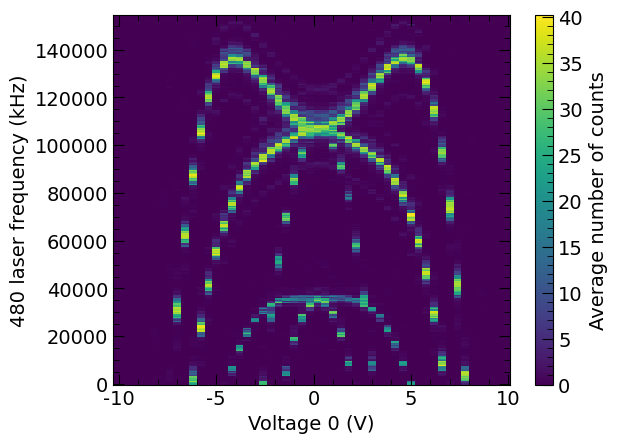

In [5]:
plt.pcolormesh(x,y,z.T)
plt.xlabel(notes["xlabel"])
plt.ylabel(notes["ylabel"])
cbar = plt.colorbar()
cbar.set_label(notes["zlabel"])